                                    DETEKCIJA PREVARA U FINANSIJAMA

Autor: Luka Đokić 2022/0312

dataset preuzet sa: https://www.kaggle.com/datasets/kartik2112/fraud-detection

In [1]:
import pandas as pd
import numpy as np
import torch
import time
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# Fiksiranje seed-a kako bismo pri svakom pokretanju koda dobili iste rezultate
torch.manual_seed(42)
np.random.seed(42)

In [3]:
#zbog prevelikog broja transakcija (broj redova > 1,5m) uzimam uzorak od 200 000 transakcija koji je
#sasvim dovoljan za ucenje modela
df = pd.read_csv("fraud.csv", nrows= 200000)
#prikaz prvih 5 redova tabele
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [4]:
#Prikaz osnovnih informacija o kolonama i tipovima podataka
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             200000 non-null  int64  
 1   trans_date_trans_time  200000 non-null  object 
 2   cc_num                 200000 non-null  int64  
 3   merchant               200000 non-null  object 
 4   category               200000 non-null  object 
 5   amt                    200000 non-null  float64
 6   first                  200000 non-null  object 
 7   last                   200000 non-null  object 
 8   gender                 200000 non-null  object 
 9   street                 200000 non-null  object 
 10  city                   200000 non-null  object 
 11  state                  200000 non-null  object 
 12  zip                    200000 non-null  int64  
 13  lat                    200000 non-null  float64
 14  long                   200000 non-nu

In [5]:
#brisemo kolonu unnamed:0 jer ona predstavlja indekse redova, nikakav koristan podatak
df = df.drop(columns=['Unnamed: 0'])
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  200000 non-null  object 
 1   cc_num                 200000 non-null  int64  
 2   merchant               200000 non-null  object 
 3   category               200000 non-null  object 
 4   amt                    200000 non-null  float64
 5   first                  200000 non-null  object 
 6   last                   200000 non-null  object 
 7   gender                 200000 non-null  object 
 8   street                 200000 non-null  object 
 9   city                   200000 non-null  object 
 10  state                  200000 non-null  object 
 11  zip                    200000 non-null  int64  
 12  lat                    200000 non-null  float64
 13  long                   200000 non-null  float64
 14  city_pop               200000 non-nu

In [6]:
# Ispis konačnih dimenzija dataset-a
print(f"Dataset: {df.shape[0]} redova, {df.shape[1]} kolona")

Dataset: 200000 redova, 22 kolona


In [7]:
# Ovo je NAJVAŽNIJI korak za fraud detection — pokazuje koliko je
# dataset imbalanced (neravnomeran)
klase = df['is_fraud'].value_counts()
procenti = df['is_fraud'].value_counts(normalize=True) * 100

print(f"Legitimne transakcije: {klase[0]} ({procenti[0]:.2f}%)")
print(f"Prevare: {klase[1]} ({procenti[1]:.2f}%)")


Legitimne transakcije: 198355 (99.18%)
Prevare: 1645 (0.82%)


PREPROCESIRANJE PODATAKA

In [8]:
# Ekstrakcija sata i dana u nedelji iz datuma transakcije
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek

# Izračunavanje starosti klijenta (u godinama) na osnovu datuma rođenja
df['dob'] = pd.to_datetime(df['dob'])
df['age'] = (pd.to_datetime('2020-01-01') - df['dob']).dt.days // 365

print("Novi feature-i kreirani:")
print(df[['hour', 'day_of_week', 'age']].describe())

# Uklanjanje identifikatora, redundantnih tekstualnih kolona i ciljne promenljive (y)
kolone_za_izbacivanje = [
    'cc_num', 'first', 'last', 'trans_num',
    'street', 'city', 'state', 'zip', 'merchant', 'job',
    'trans_date_trans_time', 'dob', 'unix_time', 'is_fraud'
]

X = df.drop(columns=kolone_za_izbacivanje)
y = df['is_fraud']

print("\nPreostale kolone u X:")
print(X.columns.tolist())

# Provera nedostajućih vrednosti (NaN) pre skaliranja
print("\nBroj nedostajućih vrednosti po kolonama:")
print(X.isna().sum())
print(f"\nUkupno NaN vrednosti: {X.isna().sum().sum()}")

# One-hot enkodiranje kategorickih varijabli uz izbacivanje jedne kolone (drop_first=True)
X = pd.get_dummies(X, columns=['category', 'gender'], drop_first=True)

# Konverzija svih podataka u float32 zbog kompatibilnosti sa PyTorch tenzorima
X = X.astype(np.float32)

print(f"\nBroj kolona nakon enkodiranja: {X.shape[1]}")
print("Nove kolone (kategorije):")
print([col for col in X.columns if 'category_' in col or 'gender_' in col])

# Izdvajanje 20% podataka za finalni test skup (uz obaveznu stratifikaciju)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Podela preostalih 80% na trening i validacioni skup
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

print(f"\nTrening skup:    {X_train.shape[0]} redova")
print(f"Validacioni skup: {X_val.shape[0]} redova")
print(f"Test skup:       {X_test.shape[0]} redova")

print(f"\nProcenat fraud-a:")
print(f"  Train: {y_train.mean() * 100:.3f}%")
print(f"  Val:   {y_val.mean() * 100:.3f}%")
print(f"  Test:  {y_test.mean() * 100:.3f}%")


#Shapiro-Wilk test normalnosti po kolonama
# p >= 0.05 → normalna raspodela → StandardScaler
# p <  0.05 → nenormalna raspodela / autlajeri → RobustScaler
# Skaleri se fituju ISKLJUČIVO na trening skupu

from scipy import stats
from sklearn.preprocessing import StandardScaler, RobustScaler

def selektivno_skaliranje(X_train, X_val, X_test, alpha=0.05):
    X_tr = X_train.astype(np.float64).copy()
    X_va = X_val.astype(np.float64).copy()
    X_te = X_test.astype(np.float64).copy()

    izvestaj = []

    for col in X_train.columns:
        # Shapiro-Wilk je ograničen na ~5000 uzoraka
        uzorak = X_train[col].sample(n=min(5000, len(X_train)), random_state=42)
        _, p = stats.shapiro(uzorak)

        # Izbor skalera na osnovu p-vrednosti
        if p >= alpha:
            skaler = StandardScaler()
            naziv  = "StandardScaler"
        else:
            skaler = RobustScaler()
            naziv  = "RobustScaler"

        # Fit samo na trening skupu, transform na svima
        X_tr[col] = skaler.fit_transform(X_train[[col]].astype(np.float64)).flatten()
        X_va[col] = skaler.transform(X_val[[col]].astype(np.float64)).flatten()
        X_te[col] = skaler.transform(X_test[[col]].astype(np.float64)).flatten()

        izvestaj.append({
            'Kolona':     col,
            'p-vrednost': round(p, 6),
            'Skaler':     naziv
        })

    df_izvestaj = pd.DataFrame(izvestaj)
    print(df_izvestaj.to_string(index=False))
    print(f"\nStandardScaler: {(df_izvestaj['Skaler'] == 'StandardScaler').sum()} kolona")
    print(f"RobustScaler:   {(df_izvestaj['Skaler'] == 'RobustScaler').sum()} kolona")

    return X_tr.values, X_va.values, X_te.values

# Primena funkcije
X_train_scaled, X_val_scaled, X_test_scaled = selektivno_skaliranje(X_train, X_val, X_test)

# Konverzija NumPy nizova u PyTorch tenzore (y se reshape-uje za BCEWithLogitsLoss)
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).reshape(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1)

print(f"\nShape X_train_tensor: {X_train_tensor.shape}")
print(f"Shape y_train_tensor: {y_train_tensor.shape}")

# Kreiranje DataLoader-a za iteriranje po batch-evima (shuffle samo za trening)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor,   y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor,  y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print("\n--- PODACI SU SPREMNI ZA NEURONSKU MREŽU ---")
print(f"Broj ulaznih kolona (input features): {X_train_scaled.shape[1]}")
print(f"Broj batch-eva u trening skupu:    {len(train_loader)}")
print(f"Broj batch-eva u validacionom skupu: {len(val_loader)}")
print(f"Broj batch-eva u test skupu:        {len(test_loader)}")

Novi feature-i kreirani:
                hour    day_of_week            age
count  200000.000000  200000.000000  200000.000000
mean       12.777065       2.970070      45.835985
std         6.838865       2.160023      17.394472
min         0.000000       0.000000      14.000000
25%         7.000000       1.000000      32.000000
50%        14.000000       3.000000      44.000000
75%        19.000000       5.000000      57.000000
max        23.000000       6.000000      95.000000

Preostale kolone u X:
['category', 'amt', 'gender', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long', 'hour', 'day_of_week', 'age']

Broj nedostajućih vrednosti po kolonama:
category       0
amt            0
gender         0
lat            0
long           0
city_pop       0
merch_lat      0
merch_long     0
hour           0
day_of_week    0
age            0
dtype: int64

Ukupno NaN vrednosti: 0

Broj kolona nakon enkodiranja: 23
Nove kolone (kategorije):
['category_food_dining', 'category_gas_transport', 

ARHITEKTURA MODELA

In [1]:
import torch.nn as nn

# Definisanje arhitekture neuronske mreže za detekciju prevara
class FraudDetectionNet(nn.Module):
    def __init__(self, input_dim, hidden1=64, hidden2=32, dropout_rate=0.3):
        super().__init__()

        # nn.Sequential spaja slojeve u linearan niz kroz koji podaci prolaze redom
        self.network = nn.Sequential(
            # Prvi skriveni sloj: prima 23 ulaza i širi ih na 64 neurona
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),                         # Aktivaciona funkcija za uvođenje nelinearnosti
            nn.Dropout(dropout_rate),          # Regularizacija koja gasi 30% neurona (sprecavanje overfitting-a)

            # Drugi skriveni sloj: smanjuje sa 64 na 32 neurona
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Izlazni sloj: svodi 32 informacije na 1 konačan broj (sirovi logit)
            nn.Linear(hidden2, 1)
        )

    # Forward metoda definiše kako podaci prolaze kroz definisanu mrežu
    def forward(self, x):
        return self.network(x)

In [10]:
import torch.optim as optim

# Kreiranje instance modela
input_dim = X_train_tensor.shape[1]  # = 23
model = FraudDetectionNet(input_dim=input_dim, hidden1=64, hidden2=32, dropout_rate=0.3)

# Prikaz arhitekture
print(model)

# Funkcija greške - Binary Cross Entropy with Logits
criterion = nn.BCEWithLogitsLoss()

# Optimizator - Adam
optimizer = optim.Adam(model.parameters(), lr=0.001)

FraudDetectionNet(
  (network): Sequential(
    (0): Linear(in_features=23, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


TRENING

In [11]:
# TRENING BEZ EARLY STOPPING-A
# Ovaj blok prikazuje trening bez Early Stopping mehanizma (50 epoha).
# Cilj je DEMONSTRIRATI da Val Loss dostiže minimum i počinje da osciluje
# što motiviše uvođenje Early Stopping-a u sledećem koraku.
# NAPOMENA: Ovaj model se NE KORISTI za evaluaciju — služi samo za analizu.
num_epochs = 50

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    #TRENING
    model.train()  # uključuje Dropout
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        # 1. Forward pass — propusti podatke kroz mrežu
        outputs = model(X_batch) # outputs = tenzor (vektor) dimenzija (32, 1)

        # 2. Izračunaj grešku
        loss = criterion(outputs, y_batch)

        # 3. Obriši stare gradijente
        optimizer.zero_grad()

        # 4. Backpropagation — izračunaj nove gradijente
        loss.backward()

        # 5. Ažuriraj težine
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)


    # --- VALIDACIJA ---
    model.eval()  # isključuje Dropout
    val_loss = 0.0

    with torch.no_grad():  # ne računaj gradijente, ne treniramo
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(f"Epoha {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

Epoha 1/50 | Train Loss: 0.0480 | Val Loss: 0.0292
Epoha 2/50 | Train Loss: 0.0313 | Val Loss: 0.0263
Epoha 3/50 | Train Loss: 0.0260 | Val Loss: 0.0206
Epoha 4/50 | Train Loss: 0.0220 | Val Loss: 0.0178
Epoha 5/50 | Train Loss: 0.0201 | Val Loss: 0.0172
Epoha 6/50 | Train Loss: 0.0191 | Val Loss: 0.0156
Epoha 7/50 | Train Loss: 0.0179 | Val Loss: 0.0152
Epoha 8/50 | Train Loss: 0.0173 | Val Loss: 0.0157
Epoha 9/50 | Train Loss: 0.0168 | Val Loss: 0.0145
Epoha 10/50 | Train Loss: 0.0169 | Val Loss: 0.0144
Epoha 11/50 | Train Loss: 0.0158 | Val Loss: 0.0141
Epoha 12/50 | Train Loss: 0.0162 | Val Loss: 0.0137
Epoha 13/50 | Train Loss: 0.0164 | Val Loss: 0.0138
Epoha 14/50 | Train Loss: 0.0155 | Val Loss: 0.0135
Epoha 15/50 | Train Loss: 0.0151 | Val Loss: 0.0139
Epoha 16/50 | Train Loss: 0.0156 | Val Loss: 0.0142
Epoha 17/50 | Train Loss: 0.0147 | Val Loss: 0.0168
Epoha 18/50 | Train Loss: 0.0147 | Val Loss: 0.0137
Epoha 19/50 | Train Loss: 0.0145 | Val Loss: 0.0152
Epoha 20/50 | Train L

EARLY STOPPING

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim

# --- EARLY STOPPING KLASA ---
class EarlyStopping:
    def __init__(self, patience=5, delta=0.0):
        self.patience = patience             # Koliko epoha čekamo pre nego što dignemo ruke
        self.delta = delta                   # Minimalni pad greške koji smatramo napretkom

        self.best_loss = float("inf")        # Greska je na pocetku najveci moguci broj
        self.no_improvement_count = 0        # Brojač epoha u kojima model ne napreduje u ucenju
        self.stop_training = False           # Za zaustavljanje petlje

    def check_early_stop(self, val_loss, model):
        # Ako je trenutni val_loss bolji (manji) od dosadašnjeg rekorda umanjenog za deltu
        if val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss        # Postavi novi rekord
            self.no_improvement_count = 0    # restartujemo brojac

            # Pošto je model napravio napredak, odmah ga sačuvaj
            torch.save(model.state_dict(), "best_fraud_model.pth")
        else:
            # Ako model nije napravio napredak, uvećaj brojač loših epoha za 1
            self.no_improvement_count += 1

            # Ako je broj loših epoha dostigao granicu strpljenja, aktiviraj prekid
            if self.no_improvement_count >= self.patience:
                self.stop_training = True


#TRENING SA EARLY STOPPING
# 1. SVEŽA instanca modela (ne nastavljamo od starog!)
torch.manual_seed(42)
model = FraudDetectionNet(input_dim=input_dim, hidden1=64, hidden2=32, dropout_rate=0.3)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()

# 2. Inicijalizacija klase: čekamo 10 epoha
early_stopping = EarlyStopping(patience=10, delta=0.0001)

# 3. Training loop SA Early Stopping-om
num_epochs = 50
train_losses_es = []
val_losses_es = []

for epoch in range(num_epochs):
    # --- FAZA TRENINGA (Učenje na osnovu gradijenata) ---
    model.train()  # Uključi Dropout (gasi 30% neurona nasumično)
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        outputs = model(X_batch)              # 1. Forward pass (paralelno za 32 transakcije)
        loss = criterion(outputs, y_batch)    # 2. Računanje prosečne BCE greške batch-a

        optimizer.zero_grad()                 # 3. Brisanje starih gradijenata
        loss.backward()                       # 4. Backpropagation (pisanje novih gradijenata kroz lanac)
        optimizer.step()                      # 5. Podesavamo nove poboljsane tezine kako bismo smanjili greske

        train_loss += loss.item()             # Sabiranje grešaka iz svih batch-eva

    avg_train_loss = train_loss / len(train_loader) # Prosečna greška cele epohe na trening podacima

    #FAZA VALIDACIJE
    model.eval()  # Isključi Dropout
    val_loss = 0.0

    with torch.no_grad():  # Isključi računanje gradijenata
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)          # Samo forward pass kroz trenutno podešene težine
            loss = criterion(outputs, y_batch) # Računanje greške na validacionim podacima
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader) # Prosečna greška cele epohe na validacionim podacima

    train_losses_es.append(avg_train_loss)
    val_losses_es.append(avg_val_loss)

    print(f"Epoha {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # --- PROVERA KOČNICE ---
    # Šaljemo trenutni prosečni val_loss u našu klasu da vidi ima li napretka
    early_stopping.check_early_stop(avg_val_loss, model)

    # Ako je klasa unutar sebe vratila True, prekidamo celu veliku for petlju
    if early_stopping.stop_training:
        print(f"\nEarly stopping aktiviran na epohi {epoch+1}.")
        print(f"Najbolji Val Loss: {early_stopping.best_loss:.4f}")
        break

print(f"\nTrening završen. Najbolji Val Loss: {early_stopping.best_loss:.4f}")

Epoha 1/50 | Train Loss: 0.0480 | Val Loss: 0.0292
Epoha 2/50 | Train Loss: 0.0313 | Val Loss: 0.0263
Epoha 3/50 | Train Loss: 0.0260 | Val Loss: 0.0206
Epoha 4/50 | Train Loss: 0.0220 | Val Loss: 0.0178
Epoha 5/50 | Train Loss: 0.0201 | Val Loss: 0.0172
Epoha 6/50 | Train Loss: 0.0191 | Val Loss: 0.0156
Epoha 7/50 | Train Loss: 0.0179 | Val Loss: 0.0152
Epoha 8/50 | Train Loss: 0.0173 | Val Loss: 0.0157
Epoha 9/50 | Train Loss: 0.0168 | Val Loss: 0.0145
Epoha 10/50 | Train Loss: 0.0169 | Val Loss: 0.0144
Epoha 11/50 | Train Loss: 0.0158 | Val Loss: 0.0141
Epoha 12/50 | Train Loss: 0.0162 | Val Loss: 0.0137
Epoha 13/50 | Train Loss: 0.0164 | Val Loss: 0.0138
Epoha 14/50 | Train Loss: 0.0155 | Val Loss: 0.0135
Epoha 15/50 | Train Loss: 0.0151 | Val Loss: 0.0139
Epoha 16/50 | Train Loss: 0.0156 | Val Loss: 0.0142
Epoha 17/50 | Train Loss: 0.0147 | Val Loss: 0.0168
Epoha 18/50 | Train Loss: 0.0147 | Val Loss: 0.0137
Epoha 19/50 | Train Loss: 0.0145 | Val Loss: 0.0152
Epoha 20/50 | Train L

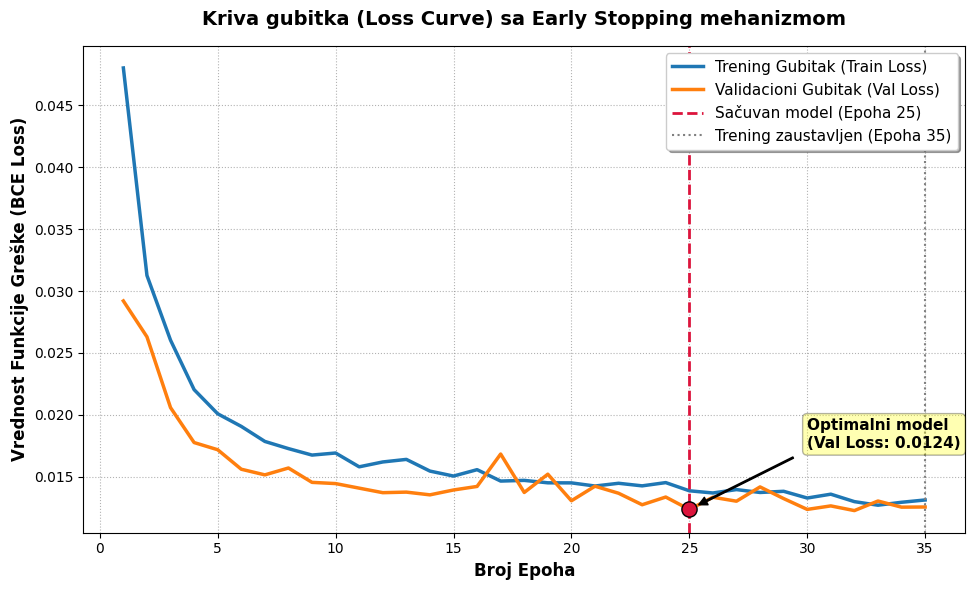

Najbolji model sačuvan na epohi: 25
Najbolji Val Loss: 0.0124
Trening zaustavljen na epohi: 35


In [13]:
import matplotlib.pyplot as plt

# Koristimo early_stopping.best_loss jer je to ono što je stvarno sačuvano
best_val_loss_value = early_stopping.best_loss
best_epoch_idx    = val_losses_es.index(best_val_loss_value)
best_epoch_num    = best_epoch_idx + 1

# Postavljamo veličinu grafika
plt.figure(figsize=(10, 6))

# Generišemo x-osu (koliko je trening stvarno trajao)
epohe = range(1, len(train_losses_es) + 1)

# 1. Crtamo glavne krive gubitka (DEO B - sa Early Stopping mehanizmom)
plt.plot(epohe, train_losses_es, label='Trening Gubitak (Train Loss)', color='#1f77b4', linewidth=2.5)
plt.plot(epohe, val_losses_es, label='Validacioni Gubitak (Val Loss)', color='#ff7f0e', linewidth=2.5)

# 2. Dodajemo vertikalnu isprekidanu crvenu liniju na X koordinati najboljeg modela
plt.axvline(x=best_epoch_num, color='crimson', linestyle='--', linewidth=2,
            label=f'Sačuvan model (Epoha {best_epoch_num})')

# 3. Stavljamo veliku crvenu tačku tačno na krivi minimalnog Val Loss-a
plt.scatter(best_epoch_num, best_val_loss_value, color='crimson', s=120, zorder=5, edgecolors='black')

# 4. Crtamo žuti tekstualni boks i strelicu (xy = vrh strelice, xytext = pozicija teksta)
plt.annotate(
    f'Optimalni model\n(Val Loss: {best_val_loss_value:.4f})',
    xy=(best_epoch_num, best_val_loss_value),
    xytext=(best_epoch_num + 5, best_val_loss_value + 0.005),
    arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6, headlength=6),
    fontsize=11,
    fontweight='bold',
    bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.3)
)

# 5. Dodajemo sivu tačkastu liniju na samom kraju grafika
stop_epoch = len(train_losses_es)
plt.axvline(x=stop_epoch, color='gray', linestyle=':', linewidth=1.5,
            label=f'Trening zaustavljen (Epoha {stop_epoch})')

# --- Podešavanje estetike grafika ---
plt.title('Kriva gubitka (Loss Curve) sa Early Stopping mehanizmom', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Broj Epoha', fontsize=12, fontweight='semibold')
plt.ylabel('Vrednost Funkcije Greške (BCE Loss)', fontsize=12, fontweight='semibold')

plt.grid(True, linestyle=':', alpha=0.6, color='gray')
plt.legend(fontsize=11, loc='upper right', frameon=True, shadow=True)
plt.tight_layout()

plt.show()

# Ispis informacija za rad
print(f"Najbolji model sačuvan na epohi: {best_epoch_num}")
print(f"Najbolji Val Loss: {best_val_loss_value:.4f}")
print(f"Trening zaustavljen na epohi: {stop_epoch}")

In [14]:
# Učitavamo NAJBOLJE sačuvane težine — one sa minimalnim Val Loss-om
model.load_state_dict(torch.load("best_fraud_model.pth", weights_only=True))

#gasimo Dropout i spremamo model za finalno testiranje
model.eval()

print(f"Najbolji model (epoha {best_epoch_num}) učitan i spreman za evaluaciju/dalje korišćenje.")

Najbolji model (epoha 25) učitan i spreman za evaluaciju/dalje korišćenje.


Analiza osetljivosti i hiperparametarska optimizacija

In [15]:
def train_model(hidden1, hidden2, dropout_rate, learning_rate, patience=10, delta=0.0001, num_epochs=50, verbose=False):
    """
    Trenira FraudDetectionNet sa zadatim hiperparametrima.
    Vraća: najbolji val_loss, broj epoha do zaustavljanja, istreniran model.
    """

    #svaka kombinacija kreće
    # iz istih početnih uslova, razlike u rezultatima se desava
    # zbog hiperparametara
    torch.manual_seed(42)

    #pravimo novu mrežu sa dimenzijama koje su prosleđene kao argumenti
    model = FraudDetectionNet(
        input_dim=input_dim,
        hidden1=hidden1,
        hidden2=hidden2,
        dropout_rate=dropout_rate
    )

    # Adam dobija specifični learning_rate za ovu rundu testiranja
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.BCEWithLogitsLoss()

    # Early stopping klasa se prilagođava zadatom strpljenju i delti
    early_stopping = EarlyStopping(patience=patience, delta=delta)

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        #TRENING
        model.train()
        train_loss = 0.0

        for X_batch, y_batch in train_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        #VALIDACIJA
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        # Ako je verbose=True, ispisujemo napredak kroz konzolu za svaku epohu
        if verbose:
            print(f"  Epoha {epoch+1}/{num_epochs} | Train: {avg_train_loss:.4f} | Val: {avg_val_loss:.4f}")

        early_stopping.check_early_stop(avg_val_loss, model)

        #prekid0 for petlje
        if early_stopping.stop_training:
            break

    # Nakon prekida, odmah učitavamo najbolji model
    model.load_state_dict(torch.load("best_fraud_model.pth", weights_only=True))
    model.eval()

    # Pakujemo sve rezultate u rečnik tako da onaj ko je pozvao funkciju može lako da ih uporedi
    return {
        "best_val_loss": early_stopping.best_loss, # Najbolja ostvarena greška
        "epochs_trained": epoch + 1,               # Broj epoha
        "train_losses": train_losses,              # Istorija trening grešaka (za crtanje grafika)
        "val_losses": val_losses,                  # Istorija validacionih grešaka (za crtanje grafika)
        "model": model                             # Vraćamo sam istrenirani model ako zatreba za test skup
    }

In [16]:
# Lista kombinacija za testiranje


konfiguracije = [
    ("Baseline (trenutna)",       64,  32, 0.3,  0.001),
    ("Manja mreža",                32,  16, 0.3,  0.001),
    ("Veća mreža",                128,  64, 0.3,  0.001),
    ("Veći Dropout",               64,  32, 0.5,  0.001),
    ("Manji Dropout",              64,  32, 0.1,  0.001),
    ("Manji learning rate",        64,  32, 0.3,  0.0001),
    ("Veći learning rate",         64,  32, 0.3,  0.01),
]

In [17]:
rezultati = []  # Prazna lista u koju ćemo ubacivati rečnike sa rezultatima

print("Pokreće se hiperparametarska analiza...\n")


for naziv, h1, h2, dr, lr in konfiguracije:
    print(f"Testiram: {naziv} (hidden=({h1},{h2}), dropout={dr}, lr={lr})")

    # Beležimo tačno vreme (u sekundama) pre početka treninga
    start_time = time.time()

    # Pozivamo našu funkciju i prosleđujemo parametre iz trenutne iteracije petlje
    result = train_model(
        hidden1=h1,
        hidden2=h2,
        dropout_rate=dr,
        learning_rate=lr,
        patience=10,
        delta=0.0001,
        num_epochs=50,
        verbose=False  # Stavili smo False da nam ne ispisuje svaku epohu i ne prlja konzolu
    )

    # Računamo koliko je sekundi prošlo
    elapsed = time.time() - start_time

    # Pakujemo sve u rečnik (ključevi će postati kolone u tabeli)
    rezultati.append({
        "Konfiguracija": naziv,
        "Hidden": f"({h1},{h2})",
        "Dropout": dr,
        "Learning Rate": lr,
        "Best Val Loss": result["best_val_loss"],
        "Epohe": result["epochs_trained"],
        "Vreme (s)": round(elapsed, 1)  # Zaokružujemo vreme na 1 decimalu zbog preglednosti
    })

    # Ispisujemo kratak izveštaj za trenutnu konfiguraciju da pratimo napredak uživo
    print(f"  -> Best Val Loss: {result['best_val_loss']:.4f} | "
          f"Epohe: {result['epochs_trained']} | "
          f"Vreme: {elapsed:.1f}s\n")



# Pretvaramo listu rečnika u Pandas DataFrame (tabelu)
df_rezultati = pd.DataFrame(rezultati)

# Sortiramo redove od najmanjeg Val Loss-a ka najvećem (jer manja greška = bolji model)
# reset_index(drop=True) postavlja lepe, nove redne brojeve (0, 1, 2...)
df_rezultati = df_rezultati.sort_values("Best Val Loss").reset_index(drop=True)

print("\n=== FINALNA TABELA REZULTATA (sortirano po Best Val Loss) ===")
# to_string(index=False) štampa tabelu u konzoli bez onih rednih brojeva 0, 1, 2... na samom početku reda
print(df_rezultati.to_string(index=False))

Pokreće se hiperparametarska analiza...

Testiram: Baseline (trenutna) (hidden=(64,32), dropout=0.3, lr=0.001)
  -> Best Val Loss: 0.0124 | Epohe: 35 | Vreme: 283.0s

Testiram: Manja mreža (hidden=(32,16), dropout=0.3, lr=0.001)
  -> Best Val Loss: 0.0133 | Epohe: 50 | Vreme: 444.6s

Testiram: Veća mreža (hidden=(128,64), dropout=0.3, lr=0.001)
  -> Best Val Loss: 0.0116 | Epohe: 29 | Vreme: 442.9s

Testiram: Veći Dropout (hidden=(64,32), dropout=0.5, lr=0.001)
  -> Best Val Loss: 0.0138 | Epohe: 50 | Vreme: 441.4s

Testiram: Manji Dropout (hidden=(64,32), dropout=0.1, lr=0.001)
  -> Best Val Loss: 0.0110 | Epohe: 42 | Vreme: 354.5s

Testiram: Manji learning rate (hidden=(64,32), dropout=0.3, lr=0.0001)
  -> Best Val Loss: 0.0146 | Epohe: 50 | Vreme: 371.8s

Testiram: Veći learning rate (hidden=(64,32), dropout=0.3, lr=0.01)
  -> Best Val Loss: 0.0221 | Epohe: 17 | Vreme: 132.9s


=== FINALNA TABELA REZULTATA (sortirano po Best Val Loss) ===
      Konfiguracija   Hidden  Dropout  Learn

In [18]:
# KOMBINOVANA KONFIGURACIJA - oba poboljšanja zajedno
print("Testiram: Kombinovano najbolje (hidden=(128,64), dropout=0.1, lr=0.001)")

start_time = time.time() # Palimo štopericu

# Pozivamo istu funkciju, ali sada sa ukrštenim najboljim vrednostima
result_combo = train_model(
    hidden1=128,
    hidden2=64,
    dropout_rate=0.1,
    learning_rate=0.001,
    patience=10,
    delta=0.0001,
    num_epochs=50,
    verbose=False
)

elapsed = time.time() - start_time

print(f"  -> Best Val Loss: {result_combo['best_val_loss']:.4f} | "
      f"Epohe: {result_combo['epochs_trained']} | "
      f"Vreme: {elapsed:.1f}s")

# Dodajemo ovaj kombinovani model u našu postojeću listu rezultata
rezultati.append({
    "Konfiguracija": "Kombinovano najbolje",
    "Hidden": "(128,64)",
    "Dropout": 0.1,
    "Learning Rate": 0.001,
    "Best Val Loss": result_combo["best_val_loss"],
    "Epohe": result_combo["epochs_trained"],
    "Vreme (s)": round(elapsed, 1)
})

# Pravimo finalnu tabelu i ponovo je sortiramo da vidimo da li je kombinovani model dao najbolji rezultat
df_rezultati_final = pd.DataFrame(rezultati)
df_rezultati_final = df_rezultati_final.sort_values("Best Val Loss").reset_index(drop=True)

print("\n=== AŽURIRANA FINALNA TABELA (sa kombinovanom konfiguracijom) ===")
print(df_rezultati_final.to_string(index=False))

Testiram: Kombinovano najbolje (hidden=(128,64), dropout=0.1, lr=0.001)
  -> Best Val Loss: 0.0119 | Epohe: 20 | Vreme: 179.9s

=== AŽURIRANA FINALNA TABELA (sa kombinovanom konfiguracijom) ===
       Konfiguracija   Hidden  Dropout  Learning Rate  Best Val Loss  Epohe  Vreme (s)
       Manji Dropout  (64,32)      0.1         0.0010       0.011003     42      354.5
          Veća mreža (128,64)      0.3         0.0010       0.011615     29      442.9
Kombinovano najbolje (128,64)      0.1         0.0010       0.011877     20      179.9
 Baseline (trenutna)  (64,32)      0.3         0.0010       0.012357     35      283.0
         Manja mreža  (32,16)      0.3         0.0010       0.013306     50      444.6
        Veći Dropout  (64,32)      0.5         0.0010       0.013818     50      441.4
 Manji learning rate  (64,32)      0.3         0.0001       0.014613     50      371.8
  Veći learning rate  (64,32)      0.3         0.0100       0.022090     17      132.9


In [19]:
#FINALNI MODEL — Manji Dropout
# najbolja konfiguracija iz hiperparametarske analize
print("Kreiram finalni model: hidden=(64,32), dropout=0.1, lr=0.001")

result_final = train_model(
    hidden1=64,
    hidden2=32,
    dropout_rate=0.1,
    learning_rate=0.001,
    patience=10,
    delta=0.0001,
    num_epochs=50,
    verbose=False
)

final_model = result_final["model"]

print("=== FINALNI MODEL — SPREMAN ZA EVALUACIJU ===")
print(f"Arhitektura: hidden_sizes=(64,32), dropout=0.1")
print(f"Best Val Loss: {result_final['best_val_loss']:.4f}")
print(f"Epoha najboljeg modela: {result_final['epochs_trained']}")
print(f"\n{final_model}")

Kreiram finalni model: hidden=(64,32), dropout=0.1, lr=0.001
=== FINALNI MODEL — SPREMAN ZA EVALUACIJU ===
Arhitektura: hidden_sizes=(64,32), dropout=0.1
Best Val Loss: 0.0110
Epoha najboljeg modela: 42

FraudDetectionNet(
  (network): Sequential(
    (0): Linear(in_features=23, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [20]:
# Eksplicitno pravimo trajnu kopiju na disku
# tako da ga neka sledeća pretraga slučajno ne obrisem
torch.save(final_model.state_dict(), "final_fraud_model.pth")
print("Finalni model sačuvan kao 'final_fraud_model.pth'")

Finalni model sačuvan kao 'final_fraud_model.pth'


In [21]:
# Provera da arhitektura odgovara
print("PROVERA ARHITEKTURE FINALNOG MODELA")
for name, param in final_model.named_parameters():
    print(f"{name}: {param.shape}")

PROVERA ARHITEKTURE FINALNOG MODELA
network.0.weight: torch.Size([64, 23])
network.0.bias: torch.Size([64])
network.3.weight: torch.Size([32, 64])
network.3.bias: torch.Size([32])
network.6.weight: torch.Size([1, 32])
network.6.bias: torch.Size([1])


EVALUACIJA MODELA

In [22]:
# Generisanje predikcija na test skupu

# Isključujemo Dropout (svi neuroni su budni) jer model više ne uči, sada ga samo propitujemo
final_model.eval()

all_probs  = []   # Ovde skupljamo procente (0.0 - 1.0) nakon Sigmoid funkcije
all_preds  = []   # Ovde skupljamo konačne binarne odluke (0 ili 1)
all_labels = []   # Ovde skupljamo tačna rešenja (šta se stvarno desilo) iz baze

# Gasimo računanje gradijenata da bismo ubrzali proces i uštedeli RAM memoriju
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        # Dobijamo sirove brojeve od modela
        logits = final_model(X_batch)

        # Pretvaramo ih u verovatnoće (od 0 do 1)
        probs = torch.sigmoid(logits)

        # Odluka! Sve preko 0.5 proglašavamo prevarom (1)
        preds = (probs >= 0.5).float()

        # Prebacujemo tenzore u obične NumPy formate i dodajemo ih u liste
        all_probs.extend(probs.numpy())
        all_preds.extend(preds.numpy())
        all_labels.extend(y_batch.numpy())

# Pretvaramo matrice oblika [[0], [1]] u obične nizove [0, 1]
all_probs  = np.array(all_probs).flatten()
all_preds  = np.array(all_preds).flatten()
all_labels = np.array(all_labels).flatten()

print(f"Broj test primera: {len(all_labels)}")
print(f"Broj predviđenih fraud (1): {int(all_preds.sum())}")
print(f"Broj stvarnih fraud (1): {int(all_labels.sum())}")

Broj test primera: 40000
Broj predviđenih fraud (1): 278
Broj stvarnih fraud (1): 329


EVALUCIONE METRIKE

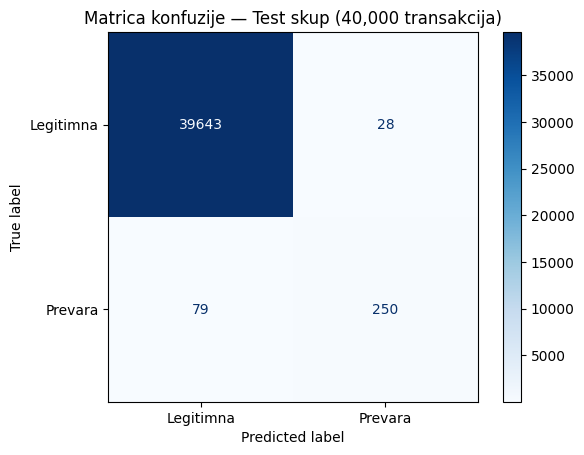

Matrica konfuzije (sirovi brojevi):
[[39643    28]
 [   79   250]]

True Negative (TN)  — tačno predviđeno LEGITIMNO: 39643
False Positive (FP) — pogrešno označeno kao FRAUD:  28
False Negative (FN) — propuštena prevara:           79
True Positive (TP)  — tačno predviđeno FRAUD:       250


In [23]:
# Matrica konfuzije
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimna', 'Prevara'])
disp.plot(cmap="Blues", values_format='d')
plt.title("Matrica konfuzije — Test skup (40,000 transakcija)")
plt.show()

print("Matrica konfuzije (sirovi brojevi):")
print(cm)

# Raščlanjivanje na 4 kategorije
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negative (TN)  — tačno predviđeno LEGITIMNO: {tn}")
print(f"False Positive (FP) — pogrešno označeno kao FRAUD:  {fp}")
print(f"False Negative (FN) — propuštena prevara:           {fn}")
print(f"True Positive (TP)  — tačno predviđeno FRAUD:       {tp}")

In [24]:
from sklearn.metrics import classification_report, accuracy_score

accuracy = accuracy_score(all_labels, all_preds)
print(f"Ukupna tačnost (Accuracy): {accuracy*100:.2f}%\n")

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=['Legitimna', 'Prevara'], digits=4))

Ukupna tačnost (Accuracy): 99.73%

Classification Report:
              precision    recall  f1-score   support

   Legitimna     0.9980    0.9993    0.9987     39671
     Prevara     0.8993    0.7599    0.8237       329

    accuracy                         0.9973     40000
   macro avg     0.9486    0.8796    0.9112     40000
weighted avg     0.9972    0.9973    0.9972     40000



ROC-AUC: 0.9900
PR-AUC (Average Precision): 0.8421


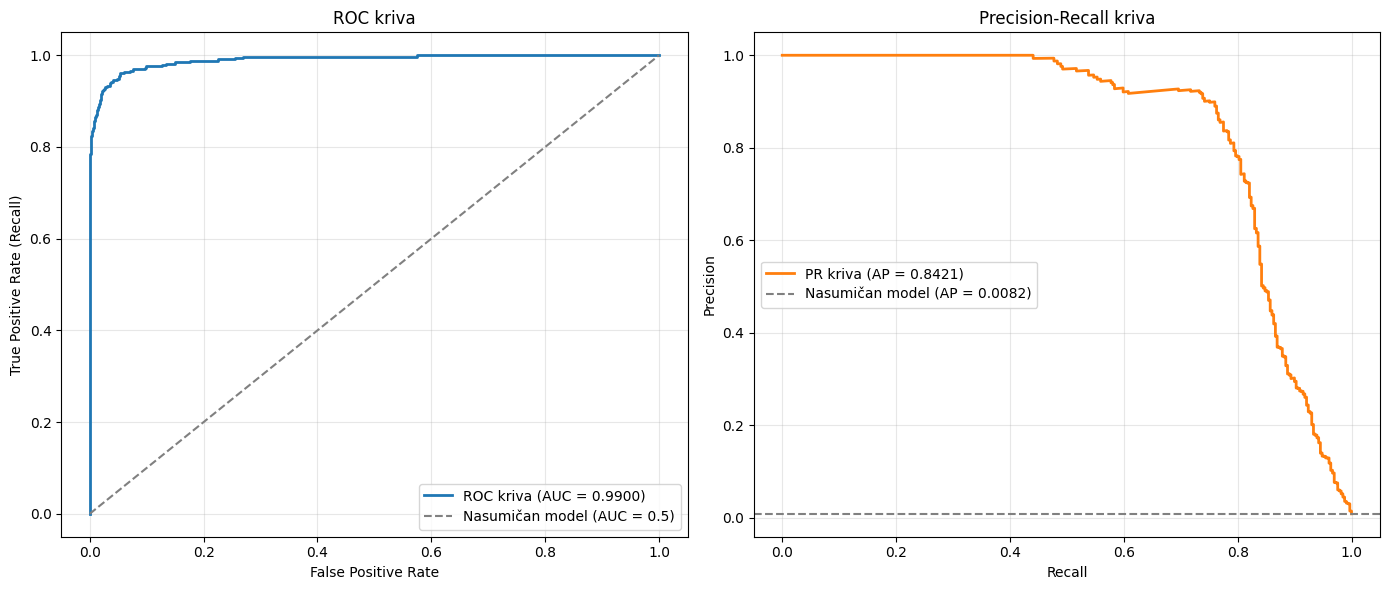

In [25]:
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score

# Izračunavanje ROC-AUC vrednosti
roc_auc = roc_auc_score(all_labels, all_probs)
print(f"ROC-AUC: {roc_auc:.4f}")

# Izračunavanje PR-AUC (Average Precision)
pr_auc = average_precision_score(all_labels, all_probs)
print(f"PR-AUC (Average Precision): {pr_auc:.4f}")

# Vizualizacija obe krive
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# LEVI GRAFIK: ROC kriva
fpr, tpr, _ = roc_curve(all_labels, all_probs)
axes[0].plot(fpr, tpr, color='#1f77b4', linewidth=2, label=f'ROC kriva (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Nasumičan model (AUC = 0.5)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC kriva')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# DESNI GRAFIK: Precision-Recall kriva
precision, recall, _ = precision_recall_curve(all_labels, all_probs)
baseline_pr = all_labels.sum() / len(all_labels)

axes[1].plot(recall, precision, color='#ff7f0e', linewidth=2, label=f'PR kriva (AP = {pr_auc:.4f})')
axes[1].axhline(y=baseline_pr, color='gray', linestyle='--', label=f'Nasumičan model (AP = {baseline_pr:.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall kriva')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
# === THRESHOLD TUNING — tražimo optimalni prag ===
pragovi = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

rezultati_pragovi = []

for prag in pragovi:
    preds_t = (all_probs >= prag).astype(float)

    tn_t, fp_t, fn_t, tp_t = confusion_matrix(all_labels, preds_t).ravel()

    precision_t = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
    recall_t    = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
    f1_t = 2 * precision_t * recall_t / (precision_t + recall_t) if (precision_t + recall_t) > 0 else 0

    rezultati_pragovi.append({
        "Prag": prag, "TP": tp_t, "FP": fp_t, "FN": fn_t,
        "Precision": round(precision_t, 4),
        "Recall":    round(recall_t, 4),
        "F1":        round(f1_t, 4)
    })

df_pragovi = pd.DataFrame(rezultati_pragovi)
print("\n=== TABELA REZULTATA PO PRAGOVIMA ===")
print(df_pragovi.to_string(index=False))


=== TABELA REZULTATA PO PRAGOVIMA ===
 Prag  TP  FP  FN  Precision  Recall     F1
  0.1 282 322  47     0.4669  0.8571 0.6045
  0.2 271 121  58     0.6913  0.8237 0.7517
  0.3 262  70  67     0.7892  0.7964 0.7927
  0.4 255  46  74     0.8472  0.7751 0.8095
  0.5 250  28  79     0.8993  0.7599 0.8237
  0.6 237  20  92     0.9222  0.7204 0.8089
  0.7 197  16 132     0.9249  0.5988 0.7269


In [1]:
#napomena: detaljnija analiza koda je u README fajlu, ovde je kod samo ukratko propraćen komentarima